In [18]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [19]:
multiedges = [[], []]

graph = nx.read_gexf(path="merged_labeled_edges.gexf")

for node1 in graph.nodes:
    for node2 in graph.neighbors(node1):
        edge = graph[node1][node2]
        if len(edge) > 2:
            multiedges[1].append((edge, node1, node2))
        multiedges[0].append((edge, node1, node2))
print(len(multiedges[0]), len(multiedges[1]))
multiedges

51800 6891


[[({'weight0': 0.8, 'id': '0'}, 'odaal', 'thieh'),
  ({'weight0': 0.9, 'id': '1'}, 'odaal', 'Sharticus123'),
  ({'weight0': 0.7, 'id': '2'}, 'odaal', 'Brodellsky'),
  ({'weight0': 0.9, 'id': '3'}, 'odaal', 'Double-decker_trams'),
  ({'weight0': 0.8, 'id': '4'}, 'thieh', 'Brodellsky'),
  ({'weight0': 0.8, 'id': '5'}, 'thieh', 'Low_Goat_Stranger990'),
  ({'weight0': 0.8, 'id': '6'}, 'Sharticus123', 'odaal'),
  ({'weight0': 0.8, 'id': '7'}, 'Sharticus123', 'corrector300'),
  ({'weight0': 0.8, 'id': '8'}, 'Sharticus123', 'cvbeiro'),
  ({'weight0': 0.8, 'weight1': 0.6, 'id': '9'}, 'Brodellsky', 'odaal'),
  ({'weight0': 0.6, 'id': '10'}, 'Brodellsky', 'The_Chief_of_Whip'),
  ({'weight0': 0.9, 'id': '11'}, 'Low_Goat_Stranger990', 'thieh'),
  ({'weight0': 0.9, 'id': '12'}, 'corrector300', 'Sharticus123'),
  ({'weight0': 0.8, 'id': '13'}, 'cvbeiro', 'Sharticus123'),
  ({'weight0': -0.6, 'id': '14'}, 'The_Chief_of_Whip', 'Brodellsky'),
  ({'weight0': 0.3, 'id': '15'}, 'aramis34143', 'Brodellsky'

In [20]:
deviations = [[], []]

for i in range(2):
    for edge, node1, node2 in multiedges[i]:
        data = np.array([float(val) for (key, val) in edge.items() if "weight" in key])
        mean = np.mean(data)
        deviation = np.abs(data - mean)
        avg_abs_deviation = np.mean(deviation)
        deviations[i].append(np.array((avg_abs_deviation, node1, node2)))

deviations = (np.array(deviations[0]), np.array(deviations[1]))
deviations[0]

array([['0.0', 'odaal', 'thieh'],
       ['0.0', 'odaal', 'Sharticus123'],
       ['0.0', 'odaal', 'Brodellsky'],
       ...,
       ['0.0', '69iamtheliquor69', 'ffnnhhw'],
       ['0.0', 'the_depressed_boerg', 'ffnnhhw'],
       ['0.0', 'GeerJonezzz', 'benzotryptamine']],
      shape=(51800, 3), dtype='<U32')

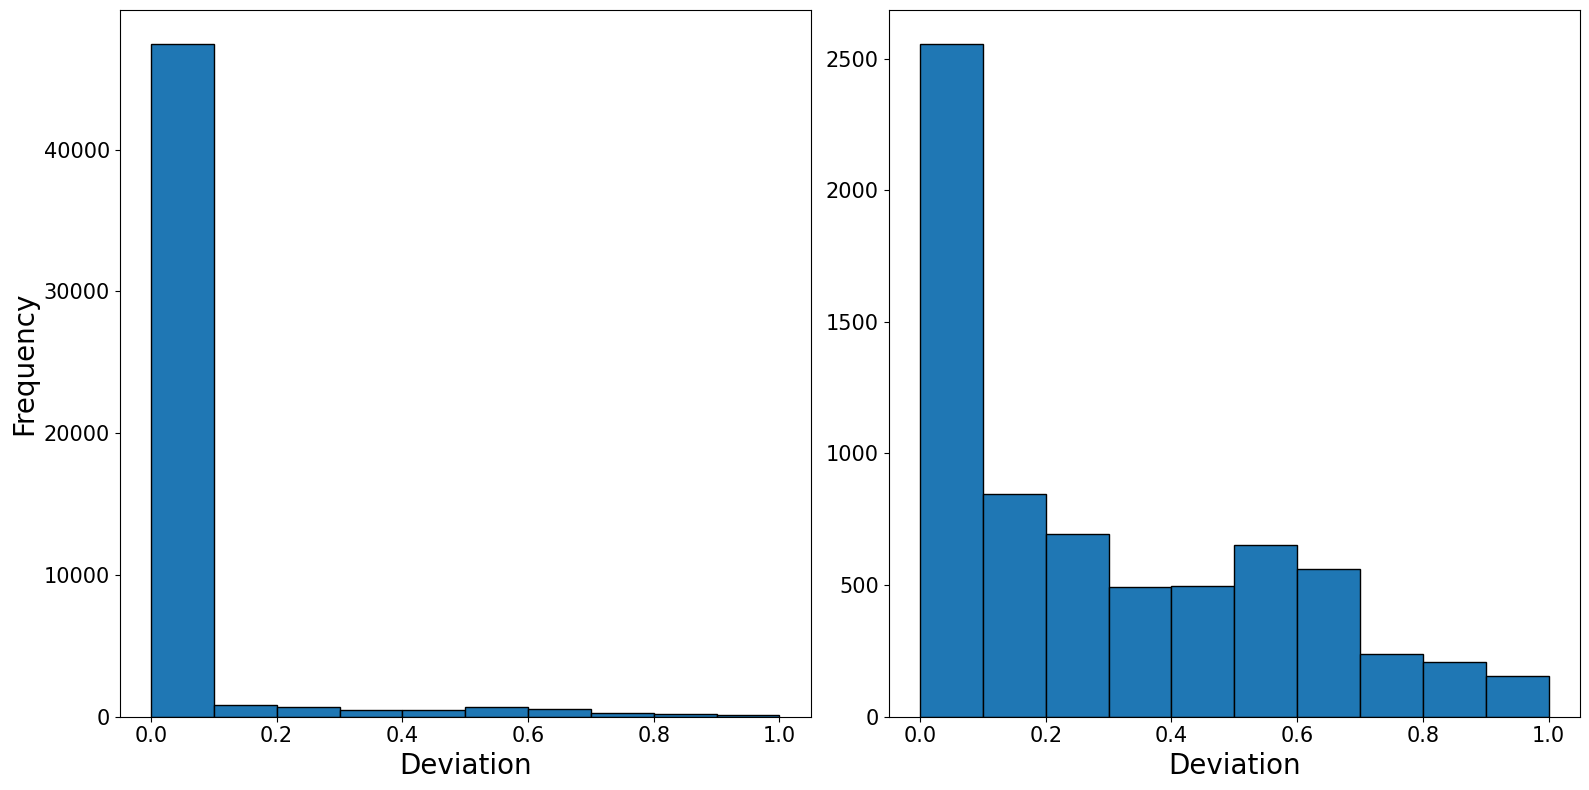

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].set_ylabel('Frequency', fontsize=20)

for i in range(2):
    axes[i].set_xlabel('Deviation', fontsize=20)
    axes[i].hist(deviations[i][:, 0].astype(float), bins=10, edgecolor='black')
    axes[i].tick_params(labelsize=15)
    
plt.tight_layout()
plt.show()

In [30]:
threshold = 0.3

above_threshold = [(str(a), str(b)) for a, b in deviations[0][deviations[0][:, 0].astype(float) > threshold][:, 1:3]]

print(len(above_threshold))
above_threshold

2796


[('Odd_Wolverine5805', 'JimboAltAlt'),
 ('i_tyrant', '427895'),
 ('427895', 'RelaxPrime'),
 ('RelaxPrime', '427895'),
 ('polite_alpha', '427895'),
 ('WonderNastyMan', 'ClydePossumfoot'),
 ('Constant-Kick6183', 'BKGPrints'),
 ('Constant-Kick6183', 'beardsac'),
 ('Constant-Kick6183', 'lemickeynorings'),
 ('FlappyBored', 'MidnightFlame702670'),
 ('Hammeredyou', 'Clarine87'),
 ('Clarine87', 'captaincumsock69'),
 ('GiftToTheUniverse', 'Hammeredyou'),
 ('just_helping', 'BKGPrints'),
 ('just_helping', 'getawarrantfedboi'),
 ('totalkpolitics', 'WhySSNTheftBad'),
 ('I405CA', 'jrandall1017'),
 ('JonDowd762', 'arbitrageME'),
 ('Moccus', '12_0z_curls'),
 ('Moccus', 'LightOfTheElessar'),
 ('AdmiralSaturyn', 'RegressToTheMean'),
 ('AdmiralSaturyn', 'bruce_cockburn'),
 ('AdmiralSaturyn', 'Aureliamnissan'),
 ('ballmermurland', 'jrandall1017'),
 ('ballmermurland', 'truthovertribe'),
 ('ballmermurland', 'Agitated_Elephant469'),
 ('ballmermurland', 'BJPark'),
 ('ballmermurland', 'tuna_HP'),
 ('BKGPrints'

In [ ]:
graph.remove_edges_from(above_threshold)

In [ ]:
nx.write_gexf(graph, "filtered_graph.gexf")